# PBI Dimer Finite-Temperature Spectra: Singleset, Multiset, and Electronic-Ancilla Multiset

This notebook compares finite-temperature PBI dimer spectra from `multiset_spectra/pbi_ft` with electronic-ancilla multiset spectra from `multiset_spectra/pbi_ft_ancilla/dimer`. Missing files are skipped instead of raising.

In [1]:
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
from renormalizer.mps import Mpo, Mps, gs
from renormalizer.utils import OptimizeConfig, Quantity, constant

_cwd = Path.cwd().resolve()
_repo_candidate = _cwd / "multiset_spectra" / "pbi_ft_ancilla"
if (_cwd / "dimer").exists() and (_cwd.parent / "pbi_ft").exists():
    NOTEBOOK_DIR = _cwd
elif _repo_candidate.exists():
    NOTEBOOK_DIR = _repo_candidate
else:
    NOTEBOOK_DIR = _cwd
ANCILLA_ROOT = NOTEBOOK_DIR
REPO_ROOT = NOTEBOOK_DIR.parents[1]
PBI_FT_ROOT = REPO_ROOT / "multiset_spectra" / "pbi_ft"
PBI_FT_DIMER = PBI_FT_ROOT / "dimer"
ANCILLA_DIMER = ANCILLA_ROOT / "dimer"

if str(PBI_FT_ROOT) not in sys.path:
    sys.path.insert(0, str(PBI_FT_ROOT))

from pbi_model import construct_pbi_model

MODEL_NAME = "dimer"
FILE_PREFIX = "Dimer"
BOND_DIMS = (32, 64)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CARRIER_RE = re.compile(r"subtracts excited-state carrier energy ([0-9.eE+-]+) au")
COLORS = {
    "singleset": "#377eb8",
    "multiset": "#4daf4a",
    "multiset_ancilla": "#e41a1c",
}
LINESTYLES = {32: "--", 64: "-"}

print(f"pbi_ft root: {PBI_FT_DIMER}")
print(f"ancilla root: {ANCILLA_DIMER}")

2026-07-07 10:32:55,370[INFO] Using GPU: 0
2026-07-07 10:32:55,375[INFO] Use CuPy as backend
2026-07-07 10:32:55,375[INFO] cupy random seed is 2019
2026-07-07 10:32:55,376[INFO] random seed is 1092
2026-07-07 10:32:55,423[INFO] Git Commit Hash: a938bf00dd4e0c4f2b01eeac7ddfc0ca9c60b339
2026-07-07 10:32:55,425[INFO] use 64 bits


pbi_ft root: /curie-home/zengjj/Renormalizer/multiset_spectra/pbi_ft/dimer
ancilla root: /curie-home/zengjj/Renormalizer/multiset_spectra/pbi_ft_ancilla/dimer


In [2]:
def model_zpe_ha(model):
    if hasattr(model, "gs_zpe"):
        return float(model.gs_zpe)
    return sum(0.5 * float(ph.omega[0]) for mol in model.mol_list for ph in mol.ph_list)


def zero_t_one_exciton_energy_ha(model):
    opt = OptimizeConfig()
    np.random.seed(0)
    h_mpo = Mpo(model, offset=Quantity(0))
    i_mps = Mps.random(model, 1, opt.procedure[0][0], 1)
    i_mps.optimize_config = opt
    energies, _ = gs.optimize_mps(i_mps, h_mpo)
    return float(np.min(energies))


model = construct_pbi_model(MODEL_NAME)
ZERO_EXCITON_ZPE_HA = model_zpe_ha(model)
ABS_PHASE_HA = ZERO_EXCITON_ZPE_HA
ONE_EXCITON_MIN_HA = zero_t_one_exciton_energy_ha(model)
E00_HA = ONE_EXCITON_MIN_HA - ZERO_EXCITON_ZPE_HA

print(f"Zero-exciton ZPE = {ZERO_EXCITON_ZPE_HA:.10f} Ha = {ZERO_EXCITON_ZPE_HA * constant.au2ev:.9f} eV")
print(f"Zero-T one-exciton minimum = {ONE_EXCITON_MIN_HA:.10f} Ha = {ONE_EXCITON_MIN_HA * constant.au2ev:.9f} eV")
print(f"Model-derived E00 = {E00_HA:.10f} Ha = {E00_HA * constant.au2ev:.9f} eV")

2026-07-07 10:32:55,802[DEBUG] # of operator terms: 64
2026-07-07 10:32:55,803[DEBUG] Input operator terms: 64
2026-07-07 10:32:55,811[DEBUG] After combination of the same terms: 64
2026-07-07 10:32:55,812[DEBUG] symbolic mpo algorithm: qr
2026-07-07 10:32:56,191[INFO] optimization method: 2site
2026-07-07 10:32:56,193[INFO] e_rtol: 1e-06
2026-07-07 10:32:56,194[INFO] e_atol: 1e-08
2026-07-07 10:32:56,195[INFO] procedure: [[10, 0.4], [20, 0.2], [30, 0.1], [40, 0], [40, 0]]
2026-07-07 10:32:56,295[DEBUG] isweep: 0
2026-07-07 10:32:56,296[DEBUG] compress config in current loop: 10, percent: 0.4
2026-07-07 10:32:56,297[DEBUG] mps current size: 45.7KiB, Matrix product bond dim:[1, 2, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1]
2026-07-07 10:32:56,298[DEBUG] optimize site: [0, 1]
2026-07-07 10:32:56,299[DEBUG] use direct eigensolver
2026-07-07 10:32:56,425[DEBUG] energy: 0.2755987230932553
2026-07-07 10:32:56,439[DEBUG] optimize site: [1, 2]
2026-07-07 10:32:56,

Zero-exciton ZPE = 0.0438456141 Ha = 1.193099942 eV
Zero-T one-exciton minimum = 0.1205399601 Ha = 3.280059412 eV
Model-derived E00 = 0.0766943460 Ha = 2.086959471 eV


In [3]:
def load_time(data):
    key = "time_series" if "time_series" in data.files else "time series"
    return np.asarray(data[key], dtype=float)


def scalar_str(data, key, default="unknown"):
    if key not in data.files:
        return default
    value = np.asarray(data[key])
    if value.shape == ():
        return str(value.item())
    return str(value)


def log_carrier_energy_ha(path):
    log_path = Path(path).with_suffix(".log")
    if not log_path.exists():
        return 0.0
    text = log_path.read_text(errors="ignore")
    matches = CARRIER_RE.findall(text)
    return float(matches[-1]) if matches else 0.0


def saved_carrier_energy_ha(path, data):
    if "carrier_energy" in data.files:
        return float(np.asarray(data["carrier_energy"]))
    return log_carrier_energy_ha(path)


def is_multiset_like(path, data):
    method = scalar_str(data, "method", "")
    parts = set(Path(path).parts)
    return "multiset" in parts or "multiset" in method or "carrier_energy" in data.files


def autocorr_to_intensity(path, spectratype):
    data = np.load(path, allow_pickle=True)
    time_au = load_time(data)
    corr = np.asarray(data["autocorr"], dtype=np.complex128)
    if len(corr) < 100 or len(time_au) != len(corr):
        raise ValueError(f"incomplete autocorr: {len(corr)} time points")
    tau_au = time_au - time_au[0]
    dt_au = time_au[1] - time_au[0]

    if spectratype == "emi":
        if is_multiset_like(path, data):
            corr = corr * np.exp(1j * saved_carrier_energy_ha(path, data) * tau_au)
        corr = np.conjugate(corr)
        phase_energy_ha = ZERO_EXCITON_ZPE_HA
    else:
        phase_energy_ha = ABS_PHASE_HA
    corr = corr * np.exp(1j * phase_energy_ha * tau_au)

    fft_freq_au = np.fft.fftfreq(len(corr), d=dt_au) * 2.0 * np.pi
    freq_au = -fft_freq_au
    intensity = np.abs(np.fft.fft(corr))

    keep = freq_au > 0
    wavelength_nm = 1e7 / (freq_au[keep] * constant.au2cm)
    intensity = intensity[keep]
    if spectratype == "emi":
        intensity = intensity * freq_au[keep] ** 3
    else:
        intensity = intensity * freq_au[keep]
    max_intensity = np.max(intensity)
    if not np.isfinite(max_intensity) or max_intensity <= 0:
        raise ValueError("invalid spectrum normalization")
    intensity = intensity / max_intensity
    order = np.argsort(wavelength_nm)
    return wavelength_nm[order], intensity[order]


def read_curve(spec):
    path = spec["path"]
    if not path.exists():
        return None, f"missing: {path}"
    try:
        x, y = autocorr_to_intensity(path, spec["spectratype"])
    except Exception as exc:
        return None, f"unreadable: {path.name} ({type(exc).__name__}: {exc})"
    return (spec, x, y), None

In [14]:
def pbi_ft_spec(spectratype, method, chi):
    suffix = "s" if method == "singleset" else "m"
    return {
        "path": PBI_FT_DIMER / spectratype / method / f"{FILE_PREFIX}_{spectratype}_{suffix}{chi}.npz",
        "label": f"{method.replace('set', '-set')} chi={chi}",
        "group": method,
        "chi": chi,
        "spectratype": spectratype,
        "color": COLORS[method],
        "linestyle": LINESTYLES[chi],
    }


def ancilla_spec(spectratype, chi):
    return {
        "path": ANCILLA_DIMER / f"{FILE_PREFIX}_{spectratype}_ma{chi}.npz",
        "label": f"multiset-ancilla chi={chi}",
        "group": "multiset_ancilla",
        "chi": chi,
        "spectratype": spectratype,
        "color": COLORS["multiset_ancilla"],
        "linestyle": LINESTYLES[chi],
    }


def build_specs(spectratype):
    specs = []
    for chi in BOND_DIMS:
        specs.append(pbi_ft_spec(spectratype, "singleset", chi))
        specs.append(pbi_ft_spec(spectratype, "multiset", chi))
        specs.append(ancilla_spec(spectratype, chi))
    return specs


def collect_curves(specs):
    curves = []
    skipped = []
    for spec in specs:
        curve, reason = read_curve(spec)
        if reason is not None:
            skipped.append(f"{spec['label']}: {reason}")
        else:
            curves.append(curve)
    if skipped:
        print("Skipped spectra:")
        for item in skipped:
            print(f"  {item}")
    return curves


def plot_curves(curves, title, outfile, xlim=(350, 750)):
    if not curves:
        print(f"No curves available for {title}; skipped plot.")
        return None

    peak_nm, peak_y = None, -np.inf
    for _, x, y in curves:
        mask = (x >= xlim[0]) & (x <= xlim[1])
        if np.any(mask) and np.max(y[mask]) > peak_y:
            idx = np.where(mask)[0][np.argmax(y[mask])]
            peak_nm, peak_y = float(x[idx]), float(y[idx])
    zoom_xlim = xlim if peak_nm is None else (max(xlim[0], peak_nm - 5), min(xlim[1], peak_nm + 5))

    fig, (ax, ax_zoom) = plt.subplots(
        1, 2, figsize=(12.2, 4.8), gridspec_kw={"width_ratios": [2.35, 1.0]}, constrained_layout=True
    )
    for spec, x, y in curves:
        for target in (ax, ax_zoom):
            target.plot(
                x,
                y,
                label=spec["label"],
                color=spec["color"],
                linestyle=spec["linestyle"],
                linewidth=2.0,
            )

    ax.set_xlim(*xlim)
    ax_zoom.set_xlim(*zoom_xlim)
    for target in (ax, ax_zoom):
        target.set_ylim(0, 1.05)
        target.set_xlabel("Wavelength (nm)")
        target.set_ylabel("Normalized intensity")
        target.grid(alpha=0.22, linewidth=0.7)
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)
    ax_zoom.set_title(f"Peak +/- 100 nm ({zoom_xlim[0]:.0f}-{zoom_xlim[1]:.0f} nm)")
    fig.savefig(outfile, bbox_inches="tight")
    plt.show()
    return fig

Skipped spectra:
  single-set chi=32: missing: /curie-home/zengjj/Renormalizer/multiset_spectra/pbi_ft/dimer/emi/singleset/Dimer_emi_s32.npz
  multi-set chi=32: missing: /curie-home/zengjj/Renormalizer/multiset_spectra/pbi_ft/dimer/emi/multiset/Dimer_emi_m32.npz


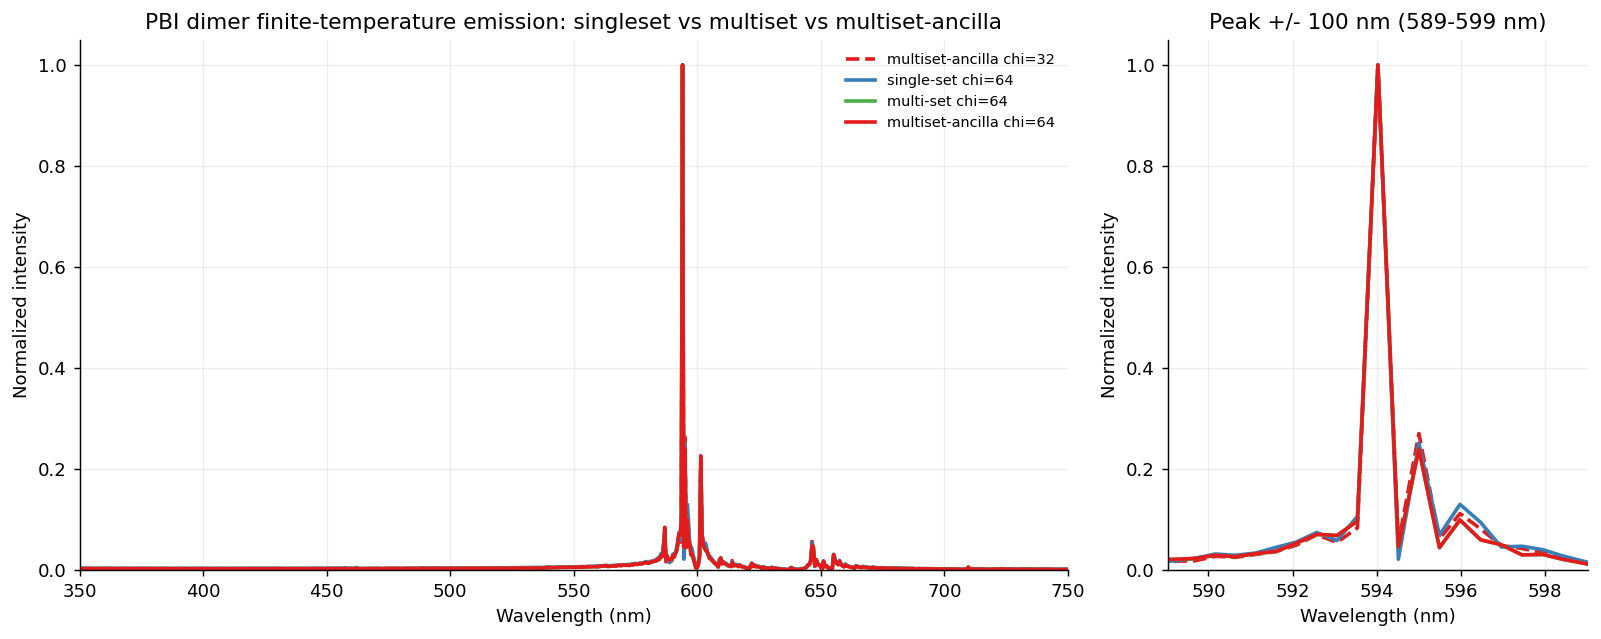

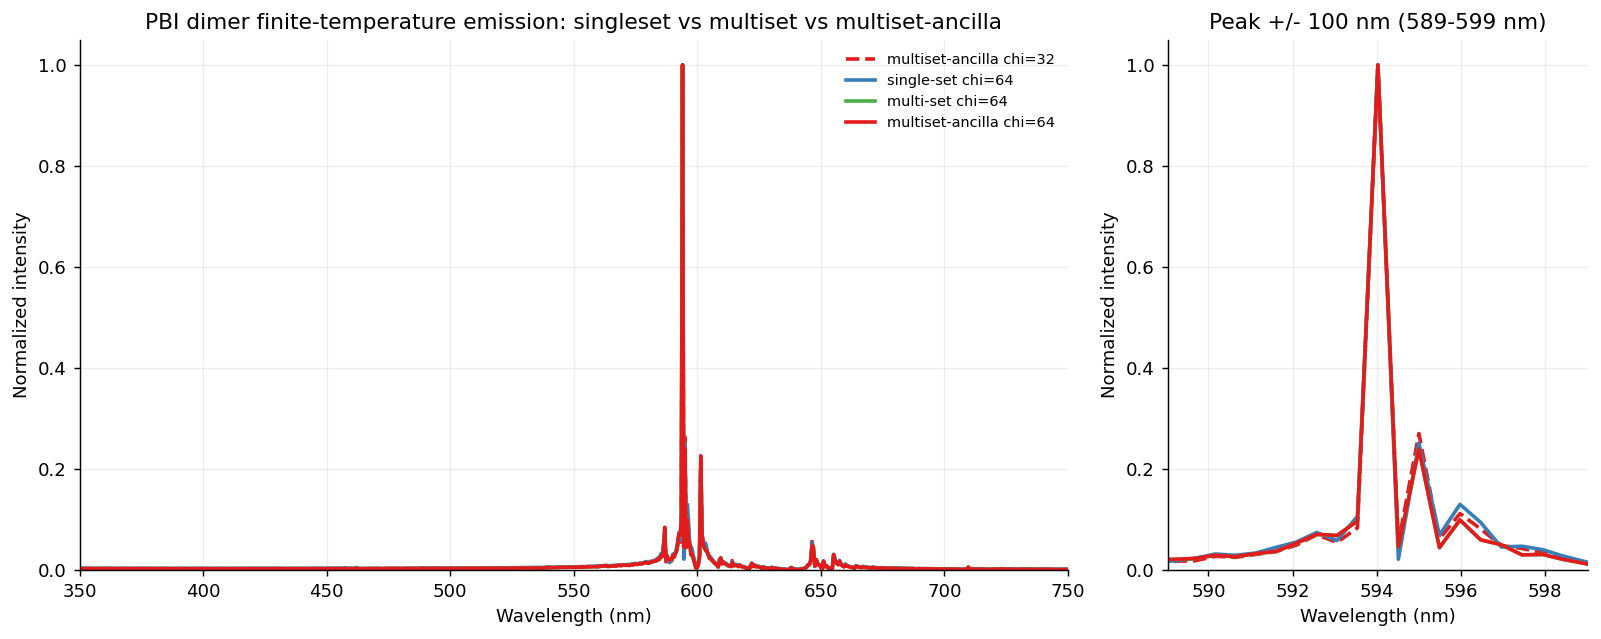

In [15]:
emi_curves = collect_curves(build_specs("emi"))
plot_curves(
    emi_curves,
    "PBI dimer finite-temperature emission: singleset vs multiset vs multiset-ancilla",
    NOTEBOOK_DIR / "dimer_emi_ancilla_compare.pdf",
)

Skipped spectra:
  single-set chi=32: missing: /curie-home/zengjj/Renormalizer/multiset_spectra/pbi_ft/dimer/abs/singleset/Dimer_abs_s32.npz
  multi-set chi=32: missing: /curie-home/zengjj/Renormalizer/multiset_spectra/pbi_ft/dimer/abs/multiset/Dimer_abs_m32.npz
  multiset-ancilla chi=32: missing: /curie-home/zengjj/Renormalizer/multiset_spectra/pbi_ft_ancilla/dimer/Dimer_abs_ma32.npz
  multiset-ancilla chi=64: missing: /curie-home/zengjj/Renormalizer/multiset_spectra/pbi_ft_ancilla/dimer/Dimer_abs_ma64.npz


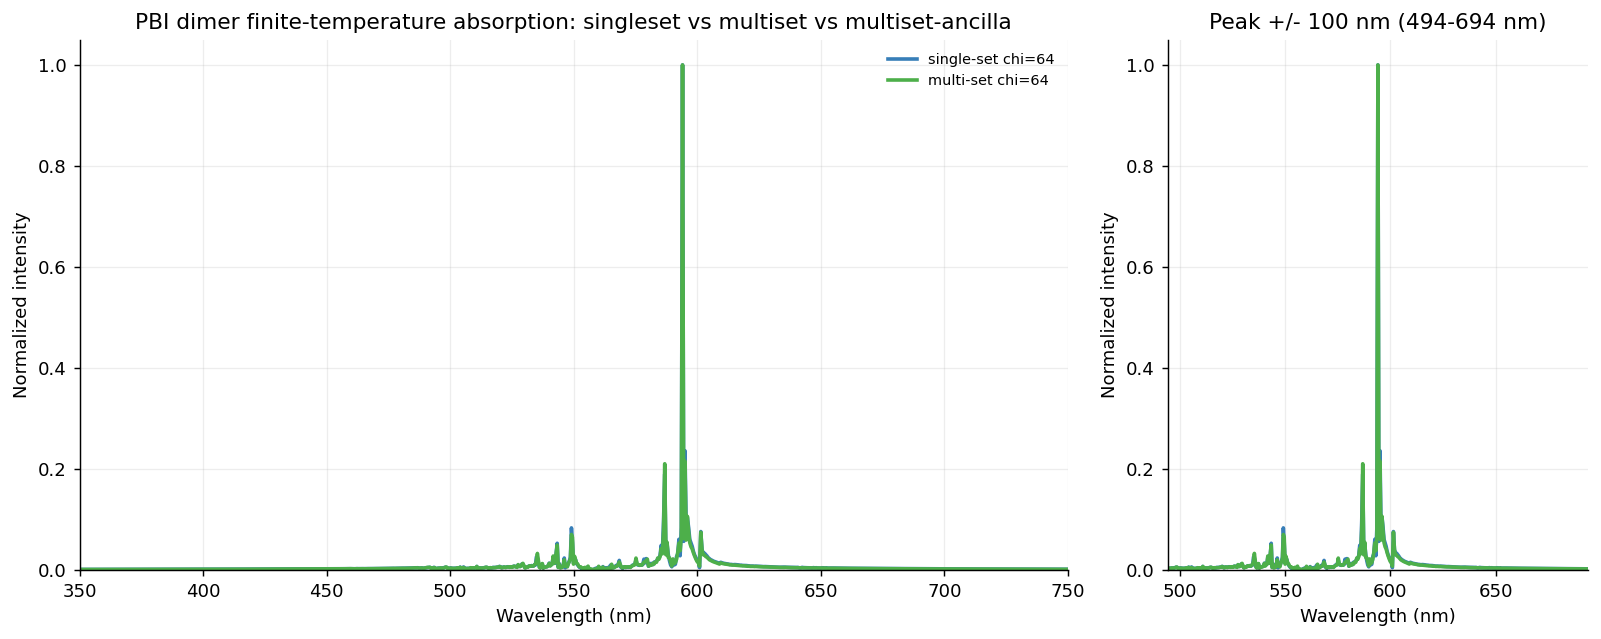

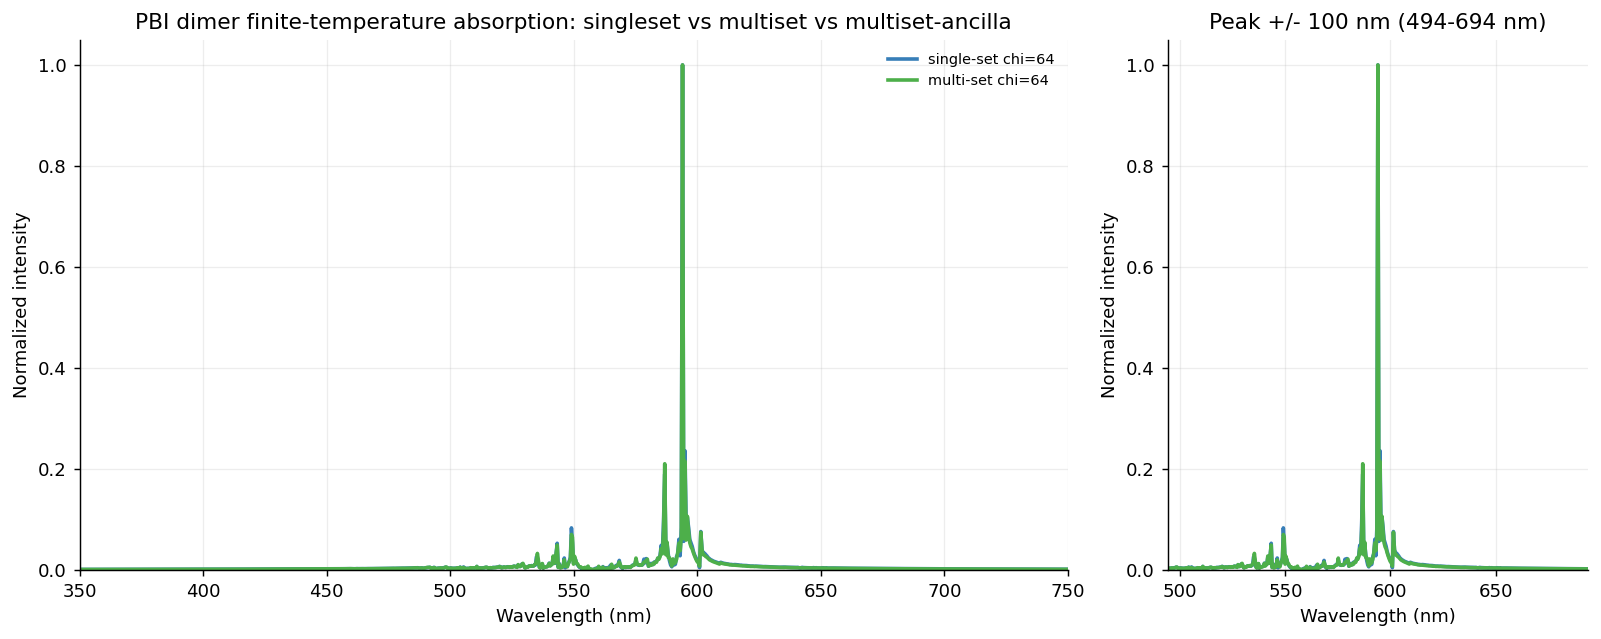

In [6]:
abs_curves = collect_curves(build_specs("abs"))
plot_curves(
    abs_curves,
    "PBI dimer finite-temperature absorption: singleset vs multiset vs multiset-ancilla",
    NOTEBOOK_DIR / "dimer_abs_ancilla_compare.pdf",
)